In [17]:
# Deep Network for Text Classification
#
# Covers: embedding layers, padding, string tokenization, and pretrained
# sentiment libraries via an introductory example.
#
# Install dependencies (run once):
#   pip install vaderSentiment nrclex matplotlib pandas tensorflow

import re

import matplotlib.pyplot as plt
import pandas as pd
from nrclex import NRCLex
from tensorflow.keras import Sequential
from tensorflow.keras.datasets import imdb
from tensorflow.keras.layers import Dense, Embedding, Flatten, SimpleRNN
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(2, 1)
    fig.suptitle(title)
    ax1.plot(history.history['loss'], label='train loss')
    ax1.plot(history.history['val_loss'], label='val loss')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax2.plot(history.history['acc'], label='train acc')
    ax2.plot(history.history['val_acc'], label='val acc')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    plt.tight_layout()
    plt.show()

print("✅ Cell 1 Complete: Libraries loaded and graphing tool ready!")

✅ Cell 1 Complete: Libraries loaded and graphing tool ready!


In [18]:
# Sep 12, 2017 tweets after iPhone X release
t1 = (
    "I'm not a huge $AAPL fan but $160 stock closes down $0.60 for the day"
    " on huge volume isn't really bearish"
)
t2 = (
    "$AAPL $BAC not sure what more dissapointing: the new iphones or the"
    " presentation for the new iphones?"
)
t3 = "IMO, $AAPL animated emojis will be the death of $SNAP."
t4 = (
    "$AAPL get on board. It's going to 175. I think wall st will have issues"
    " as aapl pushes 1 trillion dollar valuation but 175 is in the cards"
)
t5 = (
    "In the AR vs. VR battle, $AAPL just put its chips behind AR in a big way."
)
tweets = [t1, t2, t3, t4, t5]

# --- Tokenize ---
# For the tokenization process, we specified num_words as 10.
# We want to use 10 of the most frequent words and ignore any others.
# Tokenizer automatically converts text into lowercase and removes punctuation.
tokenizer = Tokenizer(num_words=10)
tokenizer.fit_on_texts(tweets)

print("Word counts:", tokenizer.word_counts)
print("Index to word:", tokenizer.index_word)
print("Word to index:", tokenizer.word_index)

# These are most frequent words.
top3_by_index = {k: tokenizer.index_word[k]
                 for k in list(tokenizer.index_word)[:3]}
top3_by_word = {k: tokenizer.word_index[k]
                for k in list(tokenizer.word_index)[:3]}
print("Top 3 by index:", top3_by_index)
print("Top 3 by word:", top3_by_word)
print("Vocabulary size:", len(tokenizer.word_index))

print("\n✅ Cell 2 Complete: Tweets tokenized!")

Word counts: OrderedDict([("i'm", 1), ('not', 2), ('a', 2), ('huge', 2), ('aapl', 6), ('fan', 1), ('but', 2), ('160', 1), ('stock', 1), ('closes', 1), ('down', 1), ('0', 1), ('60', 1), ('for', 2), ('the', 7), ('day', 1), ('on', 2), ('volume', 1), ("isn't", 1), ('really', 1), ('bearish', 1), ('bac', 1), ('sure', 1), ('what', 1), ('more', 1), ('dissapointing', 1), ('new', 2), ('iphones', 2), ('or', 1), ('presentation', 1), ('imo', 1), ('animated', 1), ('emojis', 1), ('will', 2), ('be', 1), ('death', 1), ('of', 1), ('snap', 1), ('get', 1), ('board', 1), ("it's", 1), ('going', 1), ('to', 1), ('175', 2), ('i', 1), ('think', 1), ('wall', 1), ('st', 1), ('have', 1), ('issues', 1), ('as', 1), ('pushes', 1), ('1', 1), ('trillion', 1), ('dollar', 1), ('valuation', 1), ('is', 1), ('in', 3), ('cards', 1), ('ar', 2), ('vs', 1), ('vr', 1), ('battle', 1), ('just', 1), ('put', 1), ('its', 1), ('chips', 1), ('behind', 1), ('big', 1), ('way', 1)])
Index to word: {1: 'the', 2: 'aapl', 3: 'in', 4: 'not', 

In [19]:
# The following code is used to convert text into sequences of integers.
seq = tokenizer.texts_to_sequences(tweets)
print("Integer sequences:", seq)

# Padding.
# We have used pad_sequences so that all sequences are equal in length.
pad_seq = pad_sequences(seq, maxlen=5)
print("Padded sequences (pre, default):\n", pad_seq)

# Check and see differences.
pad_seq = pad_sequences(seq, maxlen=5, padding='post', truncating='post')
print("Padded sequences (post padding + truncating):\n", pad_seq)

print("\n✅ Cell 3 Complete: Sequences padded!")

Integer sequences: [[4, 5, 6, 2, 7, 8, 1, 9, 6], [2, 4, 1, 1, 8, 1], [2, 1], [2, 9, 2, 7, 3, 1], [3, 1, 2, 3, 5]]
Padded sequences (pre, default):
 [[7 8 1 9 6]
 [4 1 1 8 1]
 [0 0 0 2 1]
 [9 2 7 3 1]
 [3 1 2 3 5]]
Padded sequences (post padding + truncating):
 [[4 5 6 2 7]
 [2 4 1 1 8]
 [2 1 0 0 0]
 [2 9 2 7 3]
 [3 1 2 3 5]]

✅ Cell 3 Complete: Sequences padded!


In [21]:
# ==========================================
# CELL 4: LEXICON SENTIMENT (MODERNIZED)
# ==========================================
import re
from nrclex import NRCLex
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

print("--- NRC EMOTION SCORES ---")
# Modern NRCLex requires a new object for every piece of text.
for tweet in tweets:
    # 1. Clean the text using the teacher's regex
    clean_words = re.findall(r'\b[a-z]+\b', tweet.lower())
    # 2. Join the words back into a string with spaces
    clean_text = ' '.join(clean_words)
    # 3. Create a brand new NRCLex object
    nrc = NRCLex(clean_text)

    print(f"NRC emotions for '{tweet[:20]}...': {nrc.affect_frequencies}")

# Testing individual words
nrc_anime = NRCLex('anime')
print(f"\nNRC emotions for 'anime': {nrc_anime.affect_frequencies}")

nrc_death = NRCLex('death')
print(f"NRC emotions for 'death': {nrc_death.affect_frequencies}")

# Different sentiment lexicons via VADER
print("\n--- VADER SCORES ---")
analyzer = SentimentIntensityAnalyzer()
for tweet in tweets:
    score = analyzer.polarity_scores(tweet)
    print(f"VADER sentiment for '{tweet[:20]}...': {score}")

print("\n✅ Cell 4 Complete: Lexicon sentiment analyzed!")

--- NRC EMOTION SCORES ---
NRC emotions for 'I'm not a huge $AAPL...': {'fear': 0.5, 'anger': 0.5, 'anticip': 0.0, 'trust': 0.0, 'surprise': 0.0, 'positive': 0.0, 'negative': 0.0, 'sadness': 0.0, 'disgust': 0.0, 'joy': 0.0}
NRC emotions for '$AAPL $BAC not sure ...': {'fear': 0.0, 'anger': 0.0, 'anticip': 0.0, 'trust': 0.0, 'surprise': 0.0, 'positive': 0.0, 'negative': 0.0, 'sadness': 0.0, 'disgust': 0.0, 'joy': 0.0}
NRC emotions for 'IMO, $AAPL animated ...': {'fear': 0.1111111111111111, 'anger': 0.1111111111111111, 'anticip': 0.0, 'trust': 0.0, 'surprise': 0.1111111111111111, 'positive': 0.1111111111111111, 'negative': 0.1111111111111111, 'sadness': 0.1111111111111111, 'disgust': 0.1111111111111111, 'joy': 0.1111111111111111, 'anticipation': 0.1111111111111111}
NRC emotions for '$AAPL get on board. ...': {'fear': 0.0, 'anger': 0.0, 'anticip': 0.0, 'trust': 0.0, 'surprise': 0.0, 'positive': 0.0, 'negative': 0.0, 'sadness': 0.0, 'disgust': 0.0, 'joy': 0.0, 'anticipation': 1.0}
NRC emot

In [22]:
# --- IMDB Data ---

# 50K movie reviews (25K positive, 25K negative sentiment comments).
# Very balanced, very sanitary.
# Already converted to numbers, cleaned and so forth.

# The following are some examples of negative reviews from IMDb labeled as 0:
# A very, very, very slow-moving, aimless movie about a distressed, drifting
# young man.
# Not sure who was more lost-the flat characters or the audience, nearly half
# of whom walked out.
# Attempting artiness with black and white and clever camera angles, the movie

# The following are some examples of positive reviews from IMDb labeled as 1:
# The best scene in the movie was when Gerardo was trying to find a song that
# kept running through his head.
# Saw the movie today and thought it was a good effort, good messages for kids.
# Loved the casting of Jimmy Buffet as the science teacher.

# At this point take a look at IMDB data frame.
# Notice the length of the text in the lists.
(train_x, train_y), (test_x, test_y) = imdb.load_data(num_words=500)

# Padding
train_x = pad_sequences(train_x, maxlen=200, padding='post')
test_x = pad_sequences(test_x, maxlen=200, padding='post')

print("✅ Cell 5 Complete: IMDB data loaded and padded!")

✅ Cell 5 Complete: IMDB data loaded and padded!


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 200, 16)           8000      
                                                                 
 flatten (Flatten)           (None, 3200)              0         
                                                                 
 dense (Dense)               (None, 16)                51216     
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                                 
Total params: 59233 (231.38 KB)
Trainable params: 59233 (231.38 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
157/157 [==============================] - 1s 4ms/step - loss: 0.6852 - acc: 0.5538 - val_loss: 0.6593 - val_acc: 0.6300
Epoch 2/10
157/157

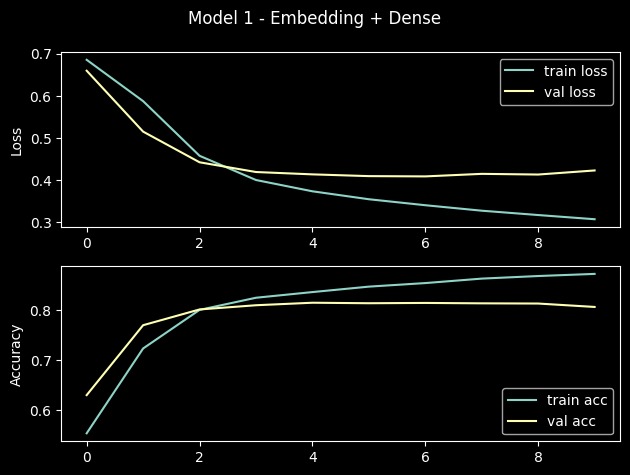

782/782 [==============================] - 1s 508us/step

--- Train Predictions ---
Actual     0  1
Predicted      
0.000069   1  0
0.000071   1  0
0.000074   1  0
0.000126   1  0
0.000127   1  0
...       .. ..
0.999835   0  1
0.999852   0  1
0.999879   0  1
0.999902   0  1
0.999929   0  1

[24865 rows x 2 columns]
782/782 [==============================] - 0s 472us/step

--- Test Predictions ---
Actual     0  1
Predicted      
0.000044   1  0
0.000118   1  0
0.000246   1  0
0.000279   1  0
0.000301   1  0
...       .. ..
0.999552   0  1
0.999604   0  1
0.999645   0  1
0.999781   0  1
0.999804   0  1

[24779 rows x 2 columns]


In [23]:
# --- Model ---

# Building a classification model.
model = Sequential([
    Embedding(input_dim=500, output_dim=16, input_length=200),
    Flatten(),
    Dense(units=16, activation='relu'),
    Dense(units=1, activation='sigmoid')
])

model.summary()

# Compile.
model.compile(optimizer='adamax',
              loss='binary_crossentropy',
              metrics=['acc'])

# Fit model.
# Don't forget to change batch size to 512 and try again.
history_1 = model.fit(train_x, train_y,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.2)

plot_history(history_1, 'Model 1 - Embedding + Dense')

# Prediction.
model.evaluate(train_x, train_y)
pred = model.predict(train_x).flatten()
print("\n--- Train Predictions ---")
print(pd.crosstab(pred, train_y, rownames=['Predicted'], colnames=['Actual']))

model.evaluate(test_x, test_y)
pred1 = model.predict(test_x).flatten()
print("\n--- Test Predictions ---")
print(pd.crosstab(pred1, test_y, rownames=['Predicted'], colnames=['Actual']))

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, None, 32)          16000     
                                                                 
 simple_rnn (SimpleRNN)      (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 18113 (70.75 KB)
Trainable params: 18113 (70.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
157/157 [==============================] - 7s 39ms/step - loss: 0.6931 - acc: 0.5045 - val_loss: 0.6910 - val_acc: 0.5156
Epoch 2/10
157/157 [==============================] - 5s 34ms/step - loss: 0.6836 - acc: 0.5473 - val_loss: 0.6880 - val_acc: 0.5224
Epoch 3/10
157/1

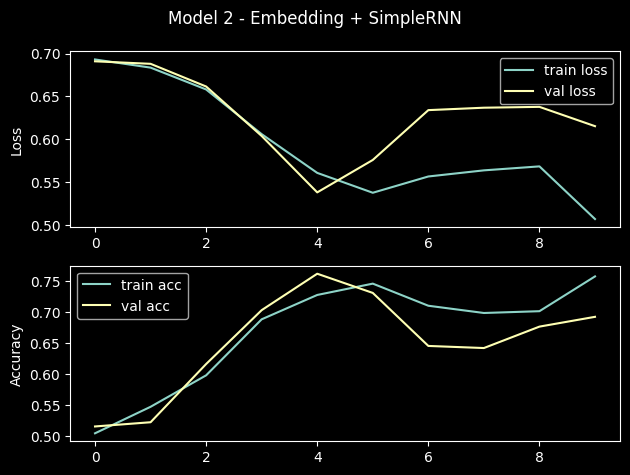

782/782 [==============================] - 3s 4ms/step - loss: 0.6047 - acc: 0.6990
✅ Cell 7 Complete: RNN model trained and evaluated!


In [24]:
# --- Possible options ---

# Playing with sequence length and optimizer: Adam, Adamax.
# I will do that in LSTMs, looks nicer there.
model2 = Sequential([
    Embedding(input_dim=500, output_dim=32),
    SimpleRNN(units=32),
    Dense(units=1, activation='sigmoid')
])
model2.summary()

# Compile model.
model2.compile(optimizer='rmsprop',
               loss='binary_crossentropy',
               metrics=['acc'])

history2 = model2.fit(train_x, train_y,
                      epochs=10,
                      batch_size=128,
                      validation_split=0.2)

plot_history(history2, 'Model 2 - Embedding + SimpleRNN')

model2.evaluate(train_x, train_y)
model2.evaluate(test_x, test_y)

print("✅ Cell 7 Complete: RNN model trained and evaluated!")